In [14]:
# Loading modules
import pandas as pd
from pandas_datareader import stooq as web
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import scipy.optimize as sciop
from math import ceil


In [15]:

def get_prices(tickers : list, period : tuple, step_size : str):
    """
    The function uses the module pandas_datareader to load data for our tickers, and checks if it has missing values


    Parameters
    ---------------------------------------------------------
    The function takes parameters tickers, period, stepsize

    tickers : list
        Tickers should be a list of valid stock ticks

    step_size : str
        Should be either a number indicating every "n"th market day or  "d","w","q","y" for daily weekly...

    period : tuple
        Should be a touple on the form (start,end) with start and end being on the form "d/m/y" example "20/4/1989" 


    Returns
    ---------------------------------------------------------
    Returns price and index

    Price : list
        Returns list of prices for each stock in ndarray

    Index : datetimeIndex (pandas)
        Returns datetimeindex for our specified step size


    Asserts
    ---------------------------------------------------------
    If first period is at a later time than second

    If we have missing values because of the stock going public at a later time than our start date etc

    """

   #Making sure dates are dd/mm/yyyy and dates are valid 
    start = pd.to_datetime(period[0], dayfirst = True)
    
    end = pd.to_datetime(period[1], dayfirst = True)

    assert start < end, "Start date should be before end date"

    df = web.StooqDailyReader(symbols = tickers, start = start, end = end).read()["Open"]


   #We check if any of the stocks have thir first price missing 
   #and assume that if it does not that it was not listed in the beginning of the period
    for i in range(len(tickers)):
      assert not np.isnan(df[tickers[i]][0]), f"{tickers[i]} was not listed in the begining of the period"

   #We forward fill any missing values in the dataset 
    df.fillna(method = "ffill", inplace = True)


    #we make a way for the function to take select strings as stepsize and translate it to an integer stepsize
    interval_translater = {"d" : 1, "daily" : 1, "w" : 5,"weekly" : 5, "m" : 21, "monthly" : 21,
                            "q" : 63, "quarterly" : 63, "y" : 252, "yearly" : 252}

    #here the numbers are given as the average trading month is 21 days,quarter is 63 and yearly is 252
    try:
      try:
        p = np.array([df[stocks][::-step_size] for stocks in tickers])

        index = df.index[::-step_size]

      except:
        p = np.array([df[stocks][::-interval_translater[step_size]] for stocks in tickers])

        index = df.index[::-interval_translater[step_size]]
        
    except:
      raise Exception("Step_size is not valid")
    



    return (p, index)


# Tickers for stocks to be implemented
tickers = ["IBM.US", "GOOGL", "AAPL", "MSFT", "MGM", "CZR"]

# stocks should be choosen such that they have all been traded on the market for the whole period given underneeth
step_size = "q"

# Period
period = ("1/1/2017", "1/1/2025")

# Get info
prices, index = get_prices(tickers, period, step_size)

/var/folders/30/f6k0bqm93bj5rgrfc_xn8glr0000gn/T/ipykernel_46102/2909215355.py:52: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  assert not np.isnan(df[tickers[i]][0]), f"{tickers[i]} was not listed in the begining of the period"
/var/folders/30/f6k0bqm93bj5rgrfc_xn8glr0000gn/T/ipykernel_46102/2909215355.py:55: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method = "ffill", inplace = True)


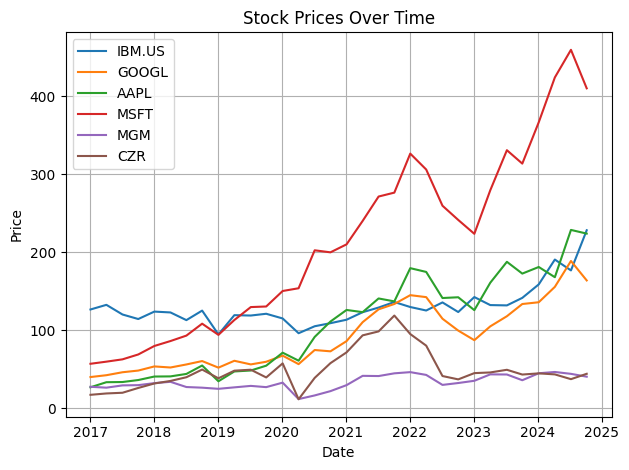

In [16]:
def stock_plot(prices: list, index: pd.DatetimeIndex, tickers:list):
  """
  A function to plot the price development of our chosen stocks(tickers) against time index.


  Parameters
  ---------------------------------------------------------
  The function takes parameters prices, index and tickers

  prices : list
    List of prices for each stock in ndarray

  index : datetimeIndex (pandas)
    Datetime index for our specified step size

  tickers : list
    A list of our chosen stock
  """

  #We plot the different stock prices
  for i in range(len(prices)):
    plt.plot(index, prices[i])
  
  
  #we set legends titles and layout
  plt.xlabel("Date")

  plt.ylabel("Price")

  plt.title("Stock Prices Over Time")

  plt.legend(tickers)

  plt.grid(True)

  plt.tight_layout()

  plt.show()

stock_plot(prices, index, tickers)


In [17]:
def get_investment_details(prices:list):
  """
  A function which calculates the correlation matrix and mean from parameter prices.

  and returns list containing mean of return for the stepsize period for each stock(ticker).
  and returns the correlation matrix

  Parameters
  ---------------------------------------------------------
  The function takes parameter pricess

  prices : list
    List of prices for each stock in ndarray

  Returns
  ---------------------------------------------------------
  Returns mu(mean) and sigma(correlation matrix)

  mu : ndarray
    Vector of means of return for the step size period for each stock(ticker)

  sigma : ndarray
    A correlation matrix for the different stocks
  
  sigma_s : ndarray
    A vector of variance of different stocks

  """
  #we calculate the returns r
  r = np.array([(prices[i][1:] - prices[i][:-1]) / prices[i][:-1] for i in range(len(prices))])

  #from that we calculate the mean return
  mu = r.mean(1).reshape(len(prices),1)

  #and the covariance matrix 
  sigma = (r - mu) @ (r - mu).T / (len(prices[0]) -1)

  #and stock variance from that
  sigma_s = np.array([sigma[i][i] for i in range(len(prices))])

  #We return the 3 with mu being reshaped from vector to standard num
  return mu.flatten(),sigma,sigma_s

mu, sigma, sigma_s = get_investment_details(prices)


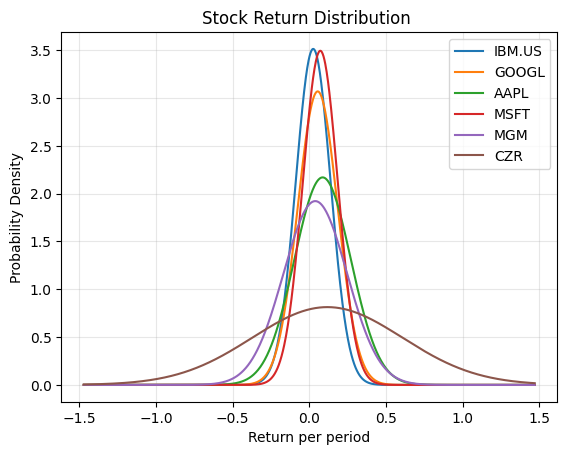

In [18]:
def return_distributions_plot(sigma_s : np.ndarray, mu : np.ndarray, tickers : list, title : str):
  """
  A function which plots the PDF of returns for the different stocks(tickers) in the same plot


  Parameters
  ---------------------------------------------------------
  The function takes parameter mu, sigma and prices

  mu : ndarray
    Vector of means of return for the step size period for each stock(ticker)

  sigma_s : ndarray
    Vector of variances for socks/portfolios that we wish to plot

  tickers : list
    A list of the names of the portfolios/stocks we want to plot

  title : str
    title for the plot

  """
  # We calculate the maximum standard deviation
  max_std = np.sqrt(max([sigma_s[i] for i in range(len(mu))]))

  # Then we define a linespace which we want to plot the function on
  linespace = np.linspace(-3 * max_std, 3 * max_std, 1000)

  # Set titles 
  plt.title(title)
  plt.ylabel('Probability Density')
  plt.xlabel('Return per period')

  # Then plot the functions on the same plot
  for i in range(len(mu)):
    plt.plot(linespace, norm.pdf(linespace, mu[i], np.sqrt(sigma_s[i])))
    
  #set legends
  plt.legend(tickers)

  plt.grid(alpha=0.3)
  
  plt.show()

return_distributions_plot(sigma_s, mu, tickers, "Stock Return Distribution ")

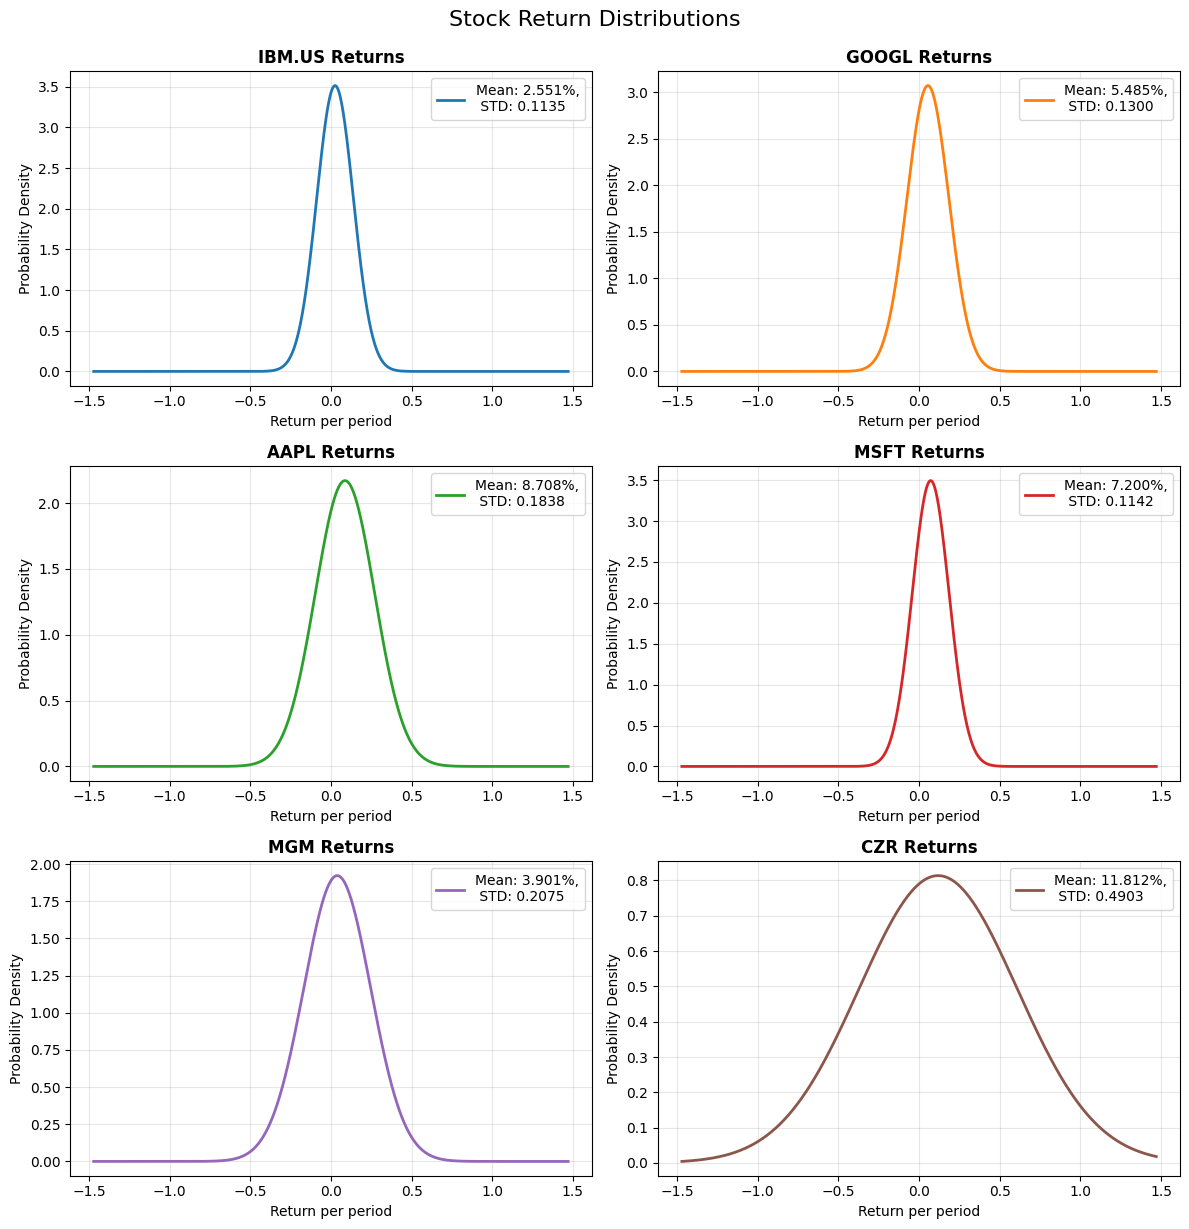

In [19]:
def return_distribution_multiplot(sigma_s : list , mu : np.ndarray , tickers : list, title : str):
  """
  A function which plots the PDF of returns for the different stocks(tickers) on different plots


  Parameters
  ---------------------------------------------------------
  The function takes parameter mu, sigma and prices

  mu : ndarray
    Vector of means of return for the step size period for each stock(ticker)

  sigma : ndarray
    Vector of variances for socks/portfolios that we wish to plot

  tickers : list
    list of names of stocks/portfolios we want to plot

  title : str
    title for the plot

  """

  #set up subplots 
  fig, axes = plt.subplots(ceil(len(mu) / 2), 2, figsize=(12, 2 * len(tickers)))
  axes = axes.flatten()
  
  #calculate the max standard deviation
  max_std = np.sqrt(max([sigma_s[i] for i in range(len(mu))]))
  
  #define linespace to plot on 
  linespace = np.linspace(-3 * max_std, 3 * max_std, 1000)
  
  # we plot the different stocks/portfolios return distribution
  for i in range(len(tickers)):
      
        mean_return = mu[i] * 100

        std = np.sqrt(sigma_s[i])

        ax = axes[i]

       #plot the function on each subplot
        ax.plot(linespace, norm.pdf(linespace, mu[i], std),
                linewidth=2, color=f'C{i}', label=f'Mean: {mean_return:.3f}%,\n STD: {std:.4f}')

       #setting legends and titles
        ax.set_title(f'{tickers[i]} Returns', fontweight='bold')

        ax.set_xlabel('Return per period')

        ax.set_ylabel('Probability Density')

        ax.grid(alpha = 0.3)
        
        ax.legend()





    # Adjust layout
  plt.tight_layout()

  plt.suptitle(title, fontsize = 16, y = 1.02)
  
  plt.show()

return_distribution_multiplot(sigma_s, mu, tickers, "Stock Return Distributions")

In [20]:
def portfolio_weights(mu : np.ndarray, sigma : np.ndarray , gammas : list):
  """
  A function which calculates the portfolio weights from a maximization problem given in the problem, for each gamma(risk factors).


  Parameters
  ---------------------------------------------------------
  The function takes parameter mu, sigma and gammas

  mu : ndarray
    Vector of means of return for the step size period for each stock(ticker)

  sigma : ndarray
    A correlation matrix for the different stocks

  gammas : list
    List of riskfactor gammas

    
  Returns
  ---------------------------------------------------------
  We return gamma_portfolios, mean_p, sigma_p and weights

  gamma_portfolios_df : DataFrame
    A dateframe with the different gammas(risk) and weights of stocks for the gamma

  mean_p : list
    A list of mean values for the different p portfolios(gammas)

  sigma_p : list
    A list of deviation for the different p portfolios(gammas)
  
  weights : list
    A list including arrays of weights for the different gammas 
  """
  #we reshape mu to a vector so we can do correct matrix multiplication
  mu = mu.reshape(len(mu),1)

# we define a wrapper function around our objective function such that we can change gamma easily
  def obj(mu,sigma,gamma):
    def obj_arb(w):
      return np.array(w).T @ mu - gamma * np.array(w).T @ sigma @ np.array(w)
    return obj_arb


  mu_p = []
  sigma_p = []
  weights = []


  # Our startguess for the maximization problem
  start_guess = np.ones(len(mu)) / len(mu)

  # Our constraint for the portfolios weights
  constraints = [{"type":"eq","fun": lambda w : np.sum(w)-1}]

  # A for loop to generate optimal portfolios and its characteristics
  for gamma in gammas:
      
      s = obj(mu,sigma,gamma)

      result = sciop.minimize(fun = lambda w: -s(w),  x0 = start_guess,  constraints = constraints)

      weights.append(result.x)

      mu_p.append(np.matmul(result.x,mu)[0])

      sigma_p.append(np.sqrt(np.matmul(np.matmul(result.x, sigma), result.x)))


# we make a dataframe simply to print it and view it
  gamma_portfolios_df = pd.DataFrame(data = weights, columns = tickers, index = [f"gamma={gamma}" for gamma in gammas])

# we return the dataframe, the caracteristics and The list of portfolio weights
  return gamma_portfolios_df, mu_p, sigma_p, weights



# Our gammas/risk
gammas = np.arange(10)/5 + 1

# Run the function
gamma_portfolios_df, mu_p, sigma_p, weights = portfolio_weights(mu,sigma, gammas)

#Print the dataframe over weights
print(gamma_portfolios_df)



             IBM.US     GOOGL      AAPL      MSFT       MGM       CZR
gamma=1.0 -0.327198 -0.681160  0.409175  1.887333 -0.398164  0.110014
gamma=1.2 -0.196294 -0.543749  0.330515  1.652208 -0.319760  0.077081
gamma=1.4 -0.090512 -0.441809  0.267879  1.481983 -0.273611  0.056069
gamma=1.6 -0.030955 -0.371274  0.237262  1.352105 -0.221814  0.034677
gamma=1.8  0.025673 -0.313339  0.200211  1.256613 -0.191433  0.022275
gamma=2.0  0.069560 -0.268004  0.173183  1.179088 -0.165541  0.011714
gamma=2.2  0.106346 -0.231073  0.153702  1.112833 -0.144083  0.002275
gamma=2.4  0.136391 -0.199678  0.136924  1.058092 -0.126168 -0.005561
gamma=2.6  0.161642 -0.173556  0.120607  1.013812 -0.111212 -0.011293
gamma=2.8  0.183610 -0.150838  0.108826  0.973767 -0.098205 -0.017160


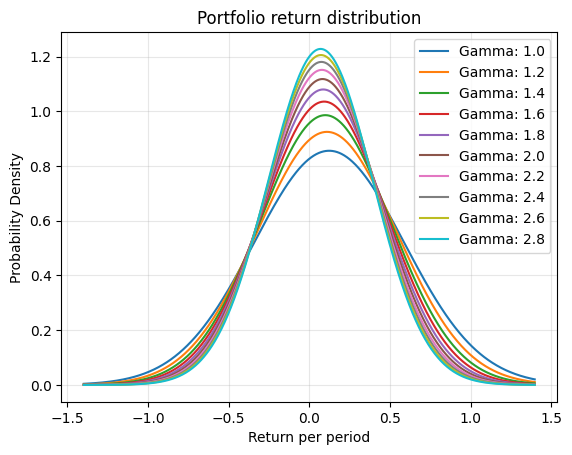

In [21]:
#we define name_gammas, this lets us reuse the plot functions from before to easily generate the plots 
name_gammas = [f"Gamma: {gamma}" for gamma in gammas]

return_distributions_plot(tickers = name_gammas, mu = mu_p, sigma_s = sigma_p, title = "Portfolio return distribution")

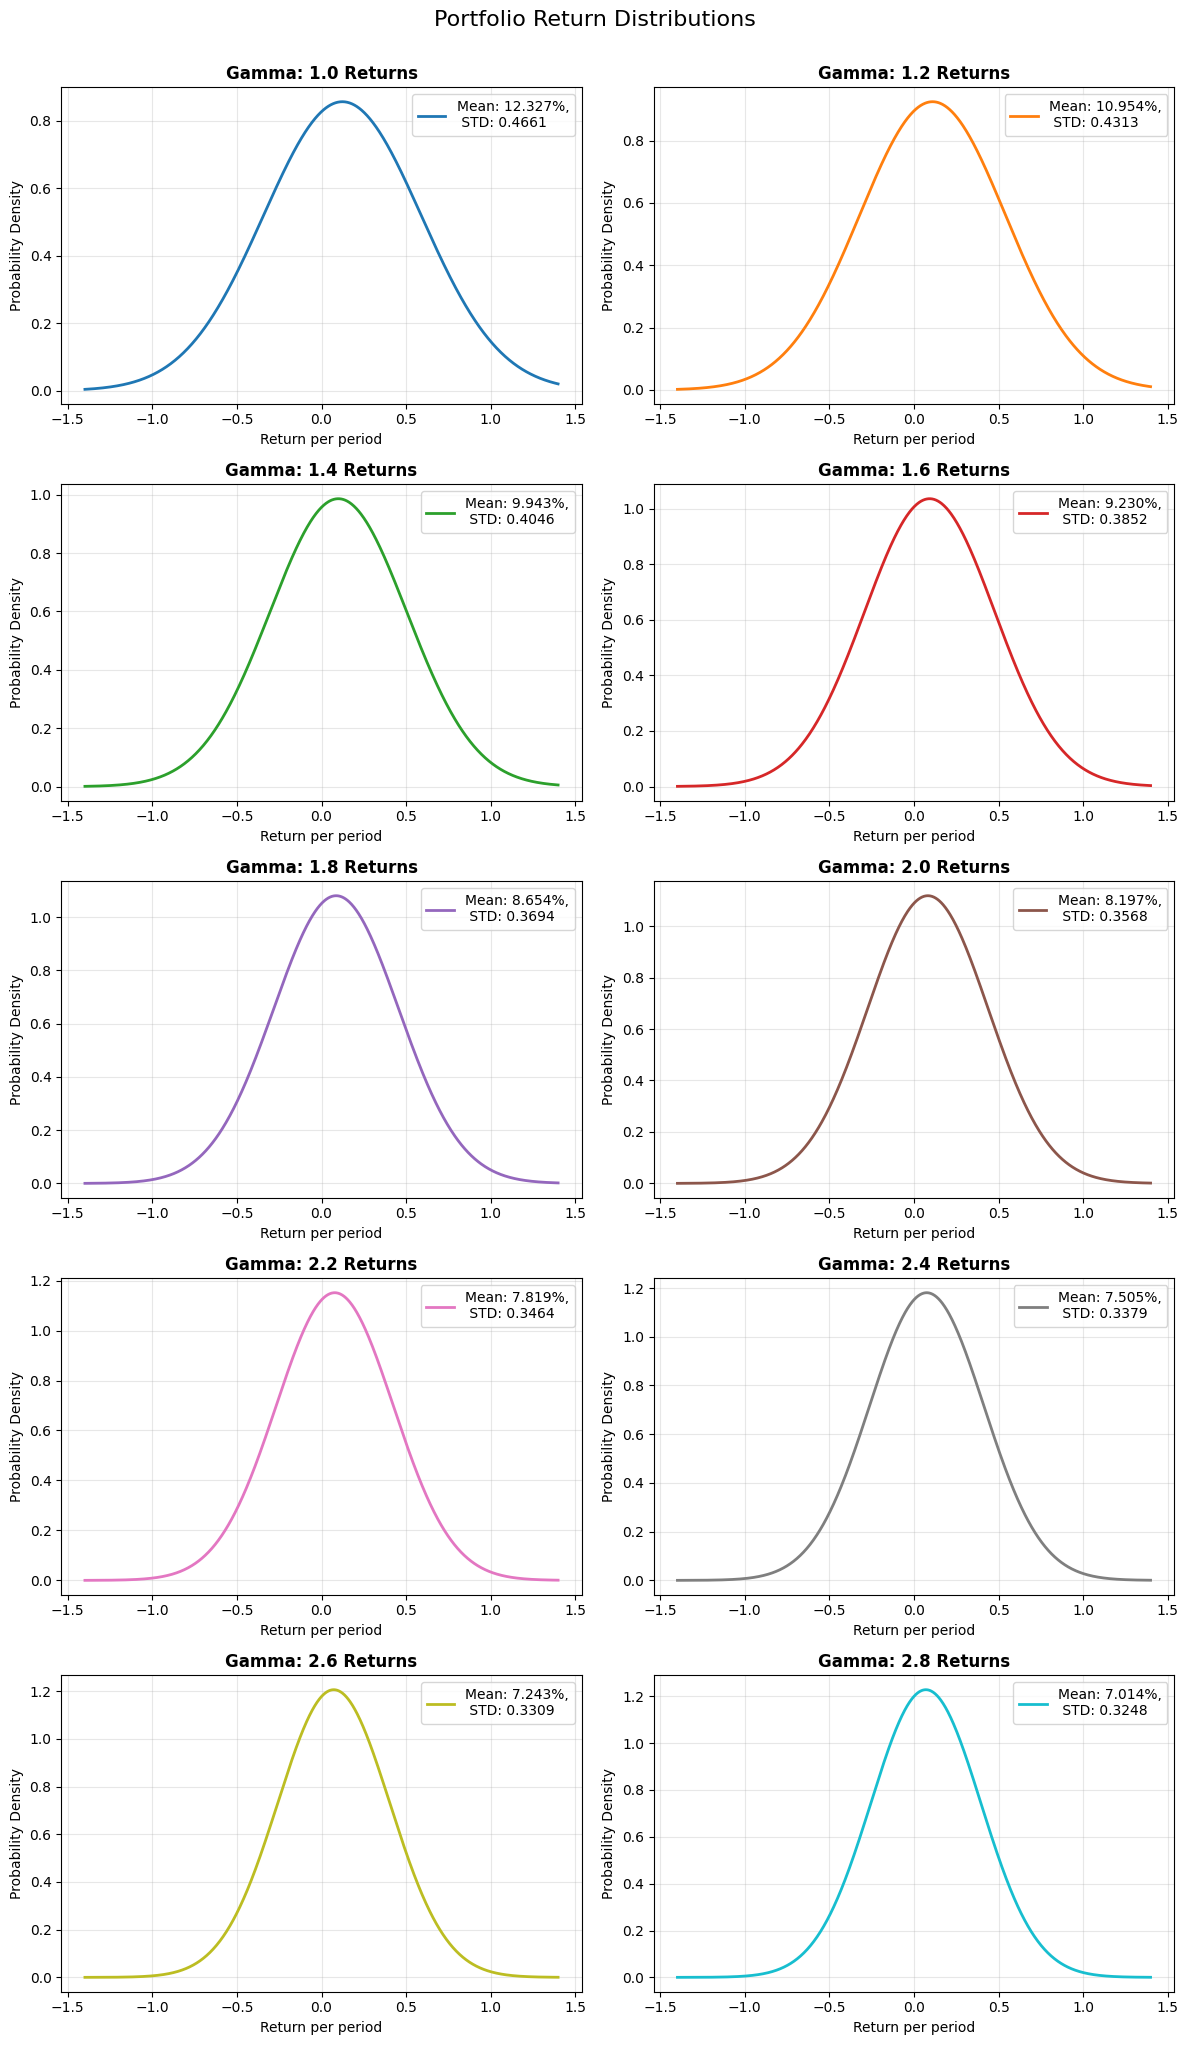

In [22]:
# again the name_gammas lets us reuse the plot functions
return_distribution_multiplot(sigma_s = sigma_p, mu = mu_p, tickers = name_gammas, title = "Portfolio Return Distributions")

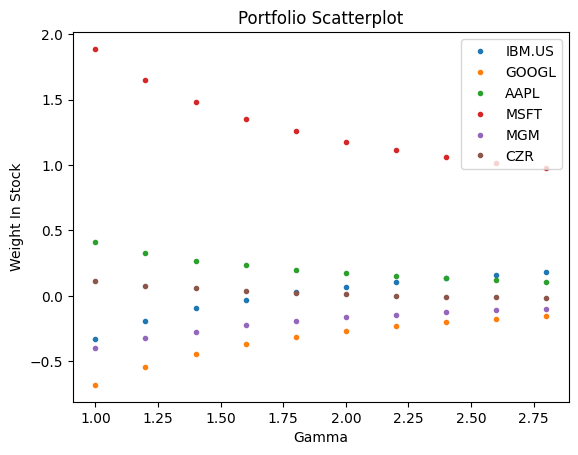

In [23]:
#we define a simple function to make a scatterplot 
def weights_scatterplot(tickers : list, weights : list, gammas : np.ndarray):
    """
    Plots the weights for different stocks under gammas

    Parameters
    ---------------------------------------------------------
    tickers : list 
        a list of the stocks in our investemt universe 
    
    weights : list
        a list of portfolios

    gammas : ndarray
        an array of gammas that were used for portfolio construction  


    """

    # create scatterplot of stock position as a function of gammas
    plt.xlabel("Gamma")

    plt.ylabel("Weight In Stock")

    plt.plot(gammas, weights, '.')

    plt.legend(tickers)

    plt.title("Portfolio Scatterplot")

    plt.show()

weights_scatterplot(tickers, weights, gammas)



In [24]:
#Minimum variance portfolio

def minimum_variance_portfolio(sigma : np.ndarray):
    """
    Calculates the minimum variance portfolio for our chosen stock

    Parameters
    ---------------------------------------------------------
    sigma : ndarray
        A correlation matrix for the different stocks 

    Returns
    ---------------------------------------------------------
    MVP_portfolio : np.ndarray
        The weights of stocks in the MVP portfolio

    """
    # A matrix of ones
    ones = np.ones(len(sigma))

    # Takes the invese of sigma
    sigma_inverse = np.linalg.inv(sigma)

    # Calculates the minimum variance portfolio seen in theory
    MVP_portfolio = sigma_inverse @ ones / (ones.T @ sigma_inverse @ ones)

    return MVP_portfolio

#calls and prints the weights of the minimum variance portfolio 
MVP_portfolio = (minimum_variance_portfolio(sigma))

print(MVP_portfolio)

[ 0.46626451  0.14477635 -0.05638661  0.46510033  0.06896434 -0.08871892]
